# Sistema de refrigeración líquida (*cold plate*)
### Simulación numérica con el método de Runge–Kutta de 4º orden (RK4)

**Integrantes**:
- Thomas Serna
- Simón Londoño
- Gabriel Serrano
- Alejandro Taborda
- Maria Fernanda Castro

**Curso:** Programación Científica 2026-1 · Universidad Nacional de Colombia

---
 El problema físico es el enfriamiento líquido monofásico de una CPU mediante una placa fría con la cadena de transferencia de calor:

$$\text{CPU} \;\rightarrow\; \text{pasta termica} \;\rightarrow\; \text{cold plate} \;\rightarrow\; \text{agua} \;\rightarrow\; \text{ambiente}.$$

## 1. Contexto físico y volúmenes de control

El sistema se representa con tres **volúmenes de control** de temperatura uniforme (modelo de parámetros concentrados):

| Volumen de control | Variable de estado | Representa |
|---|---|---|
| CPU | $T_{CPU}(t)$ | Die de silicio; ahí se genera la potencia $P_{CPU}$ |
| Cold plate | $T_{CP}(t)$ | Placa fría de cobre que recibe el calor de la CPU |
| Agua | $T_w(t)$ | Agua contenida en los canales de refrigeración |

El calor generado en la CPU se conduce hacia el cold plate a través de la pasta térmica. Desde el cold plate el calor se reparte por **dos caminos en paralelo**: la mayor parte es removida por el agua (convección forzada) y una fracción menor se disipa hacia el aire ambiente. Cada camino se modela con una **resistencia térmica equivalente** $R$, y cada volumen de control almacena energía según su **capacidad térmica** $C$.

## 2. Sistema de ecuaciones diferenciales ordinarias:

$$
C_{CPU}\,\frac{dT_{CPU}}{dt} = P_{CPU} - \frac{T_{CPU}-T_{CP}}{R_{CPU-CP}}
$$

$$
C_{CP}\,\frac{dT_{CP}}{dt} = \frac{T_{CPU}-T_{CP}}{R_{CPU-CP}} - \frac{T_{CP}-T_w}{R_{CP-w}} - \frac{T_{CP}-T_\infty}{R_{CP-a}}
$$

$$
C_w\,\frac{dT_w}{dt} = \dot m_w\, c_{p,w}\,(T_{w,in}-T_w) + \frac{T_{CP}-T_w}{R_{CP-w}}, \qquad T_{w,out}=T_w
$$

Es un sistema de **3 EDOs de primer orden, acopladas y lineales** (todos los coeficientes $C$, $R$, $\dot m_w$ son constantes).

In [63]:
#!sudo apt-get update
#!sudo apt-get install texlive-latex-extra texlive-fonts-recommended dvipng cm-super

# Librerías
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

 #Estilos
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 16,

    # Ejes y ticks
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction": "in",
    "ytick.direction": "in",

    # Grid
    "grid.color": "gray",
    "grid.linewidth": 0.3,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",

    # Estética
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "savefig.bbox": "tight",
    "savefig.dpi": 300,
})

print("Configuración OK")

# --- Paleta: tab10, con agua fijada en azul ---
COL_CPU = "#d62728"   # rojo (tab10)
COL_CP  = "#ff7f0e"   # naranja (tab10) -> se distingue bien del rojo y del azul
COL_W   = "#1f77b4"   # azul
COL_AIR = "#7f7f7f"   # gris neutro para condiciones de frontera
COL_REF = "#2ca02c"

Configuración OK


## 3. Parámetros del modelo


In [64]:
# ============================================================
# Parámetros del sistema
# ============================================================

# --- Potencia disipada por la CPU ---
P_CPU = 150.0          # [W] potencia térmica generada por la CPU

# --- Capacidades térmicas equivalentes de cada volumen de control ---
C_CPU = 15.0           # [J/K] capacidad térmica del die de la CPU
C_CP  = 120.0          # [J/K] capacidad térmica de la placa fría (cobre)
C_w   = 210.0          # [J/K] capacidad térmica del agua en los canales

# --- Resistencias térmicas equivalentes entre volúmenes de control ---
R_CPU_CP = 0.08        # [K/W] CPU -> cold plate (a través de la pasta térmica)
R_CP_w   = 0.10        # [K/W] cold plate -> agua (convección forzada)
R_CP_a   = 4.0         # [K/W] cold plate -> aire (mucho más resistivo: camino secundario)

# --- Propiedades del flujo de agua ---
m_dot_w = 0.0167       # [kg/s] caudal másico de agua (~ 1 L/min)
cp_w    = 4180.0       # [J/(kg K)] calor específico del agua

# --- Condiciones de frontera ---
T_w_in = 20.0          # [°C] temperatura del agua a la entrada del cold plate
T_inf  = 25.0          # [°C] temperatura del aire ambiente

print("Parámetros cargados.")

Parámetros cargados.


## 4. Sistema de EDOs y método numérico (RK4)

Se implementa el modelo como una función `modelo_termico(t, T)` que devuelve el vector de derivadas y se integra con un esquema explícito de **Runge–Kutta de 4º orden**.

In [65]:
def modelo_termico(t, T):
    """
    Lado derecho del sistema de EDOs.

    Parámetros
    ----------
    t : float
        Tiempo actual [s]. El sistema es autónomo (no depende
        explícitamente de t), pero se conserva el argumento para
        respetar la interfaz estándar f(t, T) de los integradores.
    T : ndarray, shape (3,)
        Vector de estado [T_CPU, T_CP, T_w] en grados Celsius.

    Retorna
    -------
    ndarray, shape (3,)
        Vector de derivadas [dT_CPU/dt, dT_CP/dt, dT_w/dt].
    """
    T_CPU, T_CP, T_w = T

    dT_CPU_dt = (
        P_CPU
        - (T_CPU - T_CP) / R_CPU_CP
    ) / C_CPU

    dT_CP_dt = (
        (T_CPU - T_CP) / R_CPU_CP
        - (T_CP - T_w) / R_CP_w
        - (T_CP - T_inf) / R_CP_a
    ) / C_CP

    dT_w_dt = (
        m_dot_w * cp_w * (T_w_in - T_w)
        + (T_CP - T_w) / R_CP_w
    ) / C_w

    return np.array([dT_CPU_dt, dT_CP_dt, dT_w_dt])


def paso_rk4(funcion, t, T, h):
    """Ejecuta un paso del método de Runge-Kutta de 4º orden (RK4)."""
    k1 = funcion(t, T)
    k2 = funcion(t + h / 2.0, T + h * k1 / 2.0)
    k3 = funcion(t + h / 2.0, T + h * k2 / 2.0)
    k4 = funcion(t + h, T + h * k3)
    return T + (h / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)


print("Modelo y método numérico definidos.")

Modelo y método numérico definidos.


## 5. Solución analítica de referencia

El sistema es **lineal e invariante en el tiempo**: cada derivada es una combinación lineal de $T_{CPU}, T_{CP}, T_w$ más una constante, de modo que puede escribirse en forma matricial

$$\frac{d\mathbf{T}}{dt} = M\,\mathbf{T} + \mathbf{f}.$$

Esto permite obtener **dos resultados exactos**, sin usar RK4:

* El **estado estacionario** $\mathbf{T}_{ss}$, resolviendo el sistema lineal $M\,\mathbf{T}_{ss} + \mathbf{f} = 0$.
* La **solución completa** $\mathbf{T}(t) = \mathbf{T}_{ss} + e^{Mt}(\mathbf{T}_0 - \mathbf{T}_{ss})$, usando la exponencial de matriz.

Esta solución analítica sirve como referencia **independiente** para validar tanto el estado estacionario como la precisión de la integración numérica (Secciones 6 y 9).

In [66]:
# ============================================================
# Solución analítica: dT/dt = M @ T + f
# ============================================================
M = np.array([
    [-1 / (C_CPU * R_CPU_CP),                             1 / (C_CPU * R_CPU_CP),                     0.0],
    [ 1 / (C_CP  * R_CPU_CP), -(1 / R_CPU_CP + 1 / R_CP_w + 1 / R_CP_a) / C_CP,       1 / (C_CP * R_CP_w)],
    [ 0.0,                                                 1 / (C_w * R_CP_w),  -(1 / R_CP_w + m_dot_w * cp_w) / C_w],
])

f_vec = np.array([
    P_CPU / C_CPU,
    T_inf / (C_CP * R_CP_a),
    (m_dot_w * cp_w * T_w_in) / C_w,
])

# Estado estacionario: 0 = M @ T_ss + f  =>  T_ss = -M^{-1} f
T_ss = -np.linalg.solve(M, f_vec)


def solucion_analitica(t, T0):
    '''Solución exacta T(t) = T_ss + expm(M t) (T0 - T_ss).'''
    return T_ss + expm(M * t) @ (T0 - T_ss)


print("Estado estacionario (analítico, sin usar RK4):")
print(f"  T_CPU_ss = {T_ss[0]:.3f} °C")
print(f"  T_CP_ss  = {T_ss[1]:.3f} °C")
print(f"  T_w_ss   = {T_ss[2]:.3f} °C")

Estado estacionario (analítico, sin usar RK4):
  T_CPU_ss = 48.811 °C
  T_CP_ss  = 36.811 °C
  T_w_ss   = 22.107 °C


## 6. Integración numérica de la simulación

Se integra desde $t=0$ hasta $t=300$ s con paso fijo $h=0.1$ s, partiendo de todo el sistema en equilibrio con el ambiente: $T_{CPU}(0)=T_{CP}(0)=T_w(0)=25\,^\circ$C.

In [67]:
# ============================================================
# Simulación principal con RK4
# ============================================================
t_inicial = 0.0
t_final = 300.0     # [s] tiempo suficiente para alcanzar el estado estacionario
h = 0.1             # [s] paso de integración

tiempos = np.arange(t_inicial, t_final + h, h)
temperaturas = np.zeros((len(tiempos), 3))

# Condición inicial: todo el sistema arranca en equilibrio con el ambiente
T0 = np.array([25.0, 25.0, 25.0])
temperaturas[0] = T0

for n in range(len(tiempos) - 1):
    temperaturas[n + 1] = paso_rk4(modelo_termico, tiempos[n], temperaturas[n], h)

T_CPU, T_CP, T_w = temperaturas[:, 0], temperaturas[:, 1], temperaturas[:, 2]
T_w_out = T_w   # el agua sale del cold plate a la temperatura del volumen de control

#  Validación contra la solución analítica (independiente de RK4)
error_final = np.abs(temperaturas[-1] - T_ss)
print("Comparación RK4 vs. solución analítica en t_final = 300 s:")
print(f"  T_CPU: {T_CPU[-1]:.4f} °C  (analítico {T_ss[0]:.4f} °C, |error| = {error_final[0]:.1e} °C)")
print(f"  T_CP : {T_CP[-1]:.4f} °C  (analítico {T_ss[1]:.4f} °C, |error| = {error_final[1]:.1e} °C)")
print(f"  T_w  : {T_w[-1]:.4f} °C  (analítico {T_ss[2]:.4f} °C, |error| = {error_final[2]:.1e} °C)")

# --- Tiempo de asentamiento: primer instante desde el cual las tres
#     temperaturas permanecen dentro de una banda del 1% respecto al
#     recorrido total (condición inicial -> estado estacionario) ---
rango = np.abs(T_ss - T0)
rango[rango == 0] = 1e-9
error_relativo = np.abs(temperaturas - T_ss) / rango
dentro_de_banda = np.all(error_relativo < 0.01, axis=1)
fuera_de_banda = np.where(~dentro_de_banda)[0]
idx_asentamiento = fuera_de_banda[-1] + 1 if len(fuera_de_banda) > 0 else 0
t_asentamiento = tiempos[idx_asentamiento]
print(f"\nTiempo de asentamiento (banda del 1%): t ≈ {t_asentamiento:.1f} s")

Comparación RK4 vs. solución analítica en t_final = 300 s:
  T_CPU: 48.8112 °C  (analítico 48.8112 °C, |error| = 5.7e-08 °C)
  T_CP : 36.8112 °C  (analítico 36.8112 °C, |error| = 5.3e-08 °C)
  T_w  : 22.1065 °C  (analítico 22.1065 °C, |error| = 7.9e-09 °C)

Tiempo de asentamiento (banda del 1%): t ≈ 72.1 s


## 7. Flujos de calor y balance de energía

A partir de las temperaturas simuladas se calculan los flujos de calor entre volúmenes de control y se verifica que en estado estacionario toda la potencia generada por la CPU se reparte, sin pérdidas, entre el camino del agua y el camino del aire.

In [68]:
# ============================================================
# Flujos de calor entre volúmenes de control
# ============================================================
Q_CPU_CP = (T_CPU - T_CP) / R_CPU_CP   # CPU -> cold plate
Q_CP_w   = (T_CP - T_w) / R_CP_w       # cold plate -> agua
Q_CP_a   = (T_CP - T_inf) / R_CP_a     # cold plate -> aire

# Verificación del balance de energía en estado estacionario
balance = Q_CP_w[-1] + Q_CP_a[-1]
frac_agua = Q_CP_w[-1] / P_CPU * 100
frac_aire = Q_CP_a[-1] / P_CPU * 100

print(f"P_CPU                 = {P_CPU:.3f} W")
print(f"Q_CP-w + Q_CP-a        = {balance:.3f} W   (debe igualar a P_CPU)")
print(f"Fracción hacia el agua = {frac_agua:.2f} %")
print(f"Fracción hacia el aire = {frac_aire:.2f} %")

# Calor removido por el agua, calculado de forma independiente a
# partir del aumento de temperatura del flujo (segunda verificación)
Q_w_removido = m_dot_w * cp_w * (T_w_out - T_w_in)
print(f"\nCalor removido por el agua, estado estacionario: {Q_w_removido[-1]:.3f} W")
print(f"Elevación de temperatura del agua (T_w,out - T_w,in): {(T_w_out - T_w_in)[-1]:.3f} °C")

P_CPU                 = 150.000 W
Q_CP-w + Q_CP-a        = 150.000 W   (debe igualar a P_CPU)
Fracción hacia el agua = 98.03 %
Fracción hacia el aire = 1.97 %

Calor removido por el agua, estado estacionario: 147.047 W
Elevación de temperatura del agua (T_w,out - T_w,in): 2.107 °C


## 8. Visualización de resultados

### Figura 1 — Evolución completa de las temperaturas

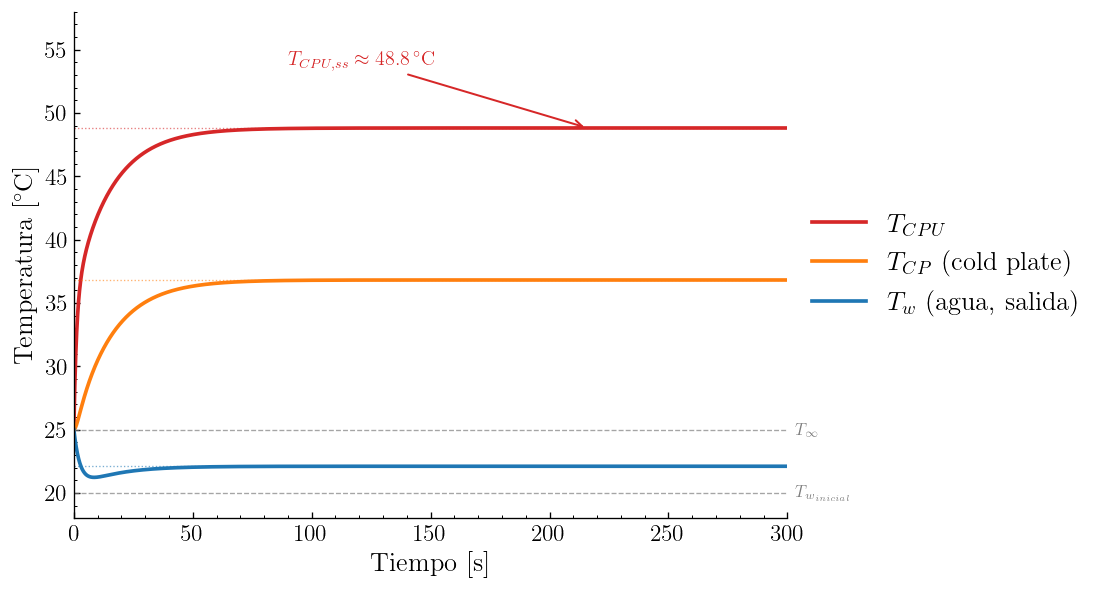

In [69]:
fig, ax = plt.subplots(figsize=(9.5, 5.2))

# Curvas principales
ax.plot(tiempos, T_CPU, color=COL_CPU, lw=2.2, label=r"$T_{CPU}$")
ax.plot(tiempos, T_CP,  color=COL_CP,  lw=2.2, label=r"$T_{CP}$ (cold plate)")
ax.plot(tiempos, T_w,   color=COL_W,   lw=2.2, label=r"$T_{w}$ (agua, salida)")

# Líneas de referencia: estado estacionario analítico
for T_val, col in zip(T_ss, [COL_CPU, COL_CP, COL_W]):
    ax.axhline(T_val, color=col, lw=0.8, ls=":", alpha=0.6)

# Condiciones de frontera (gris)
ax.axhline(T_inf, color=COL_AIR, lw=0.8, ls="--", alpha=0.7)
ax.text(t_final * 1.01, T_inf, r"$T_\infty$", color=COL_AIR, fontsize=10,
         ha="left", va="center", clip_on=False)

ax.axhline(T_w_in, color=COL_AIR, lw=0.8, ls="--", alpha=0.7)
ax.text(t_final * 1.01, T_w_in, r"$T_{w_{inicial}}$", color=COL_AIR, fontsize=10,
         ha="left", va="center", clip_on=False)

# Anotación del dato clave: temperatura de estado estacionario de la CPU
ax.annotate(
    rf"$T_{{CPU,ss}} \approx {T_ss[0]:.1f}\,^\circ$C",
    xy=(t_final * 0.72, T_ss[0]),
    xytext=(t_final * 0.30, T_ss[0] + 5),
    color=COL_CPU, fontsize=12, fontweight="bold",
    arrowprops=dict(arrowstyle="->", color=COL_CPU, lw=1.2),
)

ax.set_xlim(0, t_final)
ax.set_ylim(18, 58)
ax.set_xlabel("Tiempo [s]")
ax.set_ylabel(r"Temperatura [$^\circ$C]")

ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0, frameon=False)

plt.tight_layout()
plt.savefig("fig1_evolucion_temperaturas.png", dpi=200, bbox_inches="tight")
plt.show()

**Figura 1.** Evolución temporal de las tres temperaturas de estado desde la condición inicial ($25\,^\circ$C en todo el sistema) hasta el estado estacionario. Las líneas punteadas horizontales del color de cada curva marcan el valor de estado estacionario obtenido de forma **analítica** (Sección 5); coinciden con el resultado numérico (RK4) con un error menor a $10^{-9}\,^\circ$C, lo que valida la simulación. Las líneas grises discontinuas indican las condiciones de frontera $T_\infty$ y $T_{w_{inicial}}$, mostradas como referencia de contexto.

### Figura 2 — Transitorio inicial

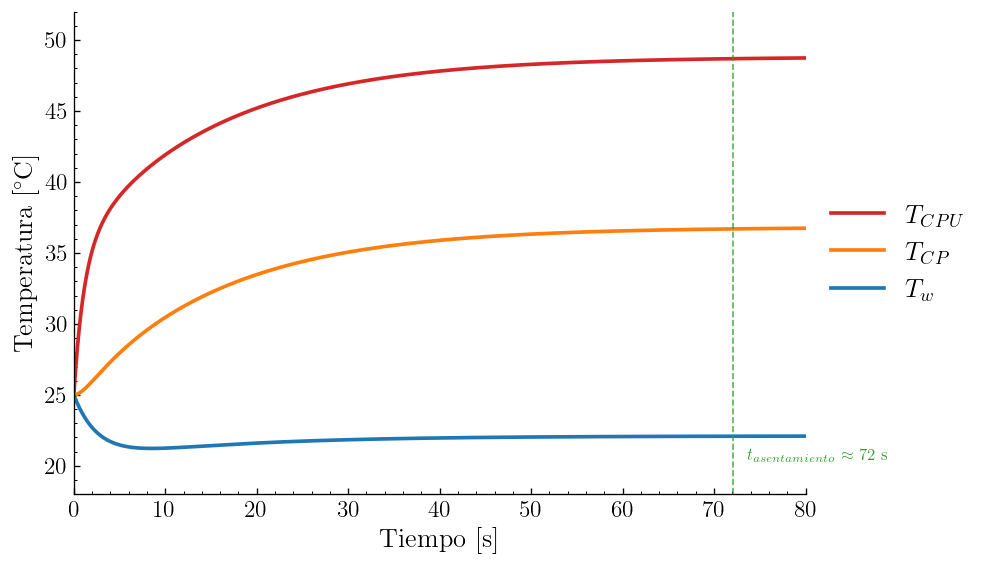

In [70]:
fig, ax = plt.subplots(figsize=(8.5, 5.0))

t_zoom = 80.0
mascara = tiempos <= t_zoom

ax.plot(tiempos[mascara], T_CPU[mascara], color=COL_CPU, lw=2.2, label=r"$T_{CPU}$")
ax.plot(tiempos[mascara], T_CP[mascara],  color=COL_CP,  lw=2.2, label=r"$T_{CP}$")
ax.plot(tiempos[mascara], T_w[mascara],   color=COL_W,   lw=2.2, label=r"$T_{w}$")

# Tiempo de asentamiento (banda del 1%), calculado en la Sección 6
ax.axvline(t_asentamiento, color=COL_REF, lw=1.0, ls="--", alpha=0.8)
ax.text(t_asentamiento + 1.5, 20.5, rf"$t_{{asentamiento}} \approx {t_asentamiento:.0f}$ s",
        color=COL_REF, fontsize=10)

ax.set_xlim(0, t_zoom)
ax.set_ylim(18, 52)
ax.set_xlabel("Tiempo [s]")
ax.set_ylabel(r"Temperatura [$^\circ$C]")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0, frameon=False)

plt.tight_layout()
plt.savefig("fig2_transitorio.png")
plt.show()

**Figura 2.** Detalle de los primeros 80 s de la simulación. La CPU (masa térmica pequeña, $C_{CPU}=15$ J/K) responde casi de inmediato al encendido, mientras que el cold plate y, sobre todo, el agua tardan más en estabilizarse por estar acoplados a través de resistencias y capacidades térmicas mayores. La línea vertical marca el tiempo de asentamiento: a partir de ese instante las tres temperaturas se mantienen dentro del 1% de su valor final.

### Figura 3 — Reparto del calor: agua vs. aire

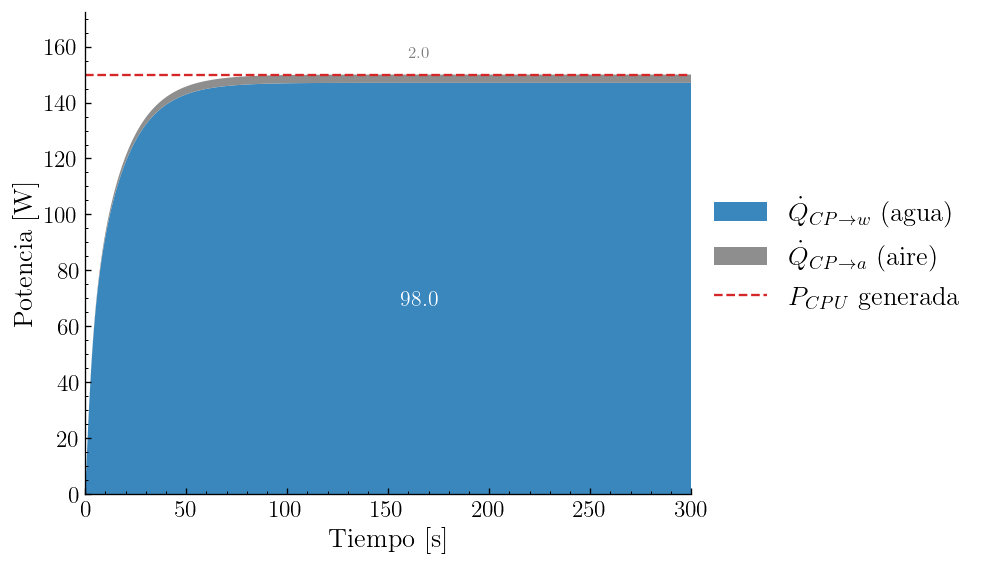

In [71]:
fig, ax = plt.subplots(figsize=(8.5, 5.0))

# Área apilada: Q_CP-w (agua) + Q_CP-a (aire) siempre suman <= P_CPU
ax.stackplot(
    tiempos, Q_CP_w, Q_CP_a,
    colors=[COL_W, COL_AIR], alpha=0.88,
    labels=[r"$\dot Q_{CP \to w}$ (agua)", r"$\dot Q_{CP \to a}$ (aire)"],
)

ax.axhline(P_CPU, color=COL_CPU, lw=1.4, ls="--", label=r"$P_{CPU}$ generada")

ax.text(t_final * 0.55, P_CPU * 0.45, f"{frac_agua:.1f}% agua",
        color="white", fontsize=13, fontweight="bold", ha="center")
ax.text(t_final * 0.55, P_CPU * 1.04, f"{frac_aire:.1f}% aire",
        color=COL_AIR, fontsize=10, ha="center", fontweight="bold")

ax.set_xlim(0, t_final)
ax.set_ylim(0, P_CPU * 1.15)
ax.set_xlabel("Tiempo [s]")
ax.set_ylabel("Potencia [W]")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0, frameon=False)

plt.tight_layout()
plt.savefig("fig3_reparto_calor.png")
plt.show()

**Figura 3.** Descomposición del calor que sale del cold plate en sus dos caminos: hacia el agua (área azul) y hacia el aire (área gris). La línea roja discontinua marca la potencia generada por la CPU. En estado estacionario, cerca del 98% del calor es removido por el agua y solo alrededor del 2% se disipa al aire (los valores exactos se anotan en la figura) lo que es consistente con lo señalado en el planteamiento del problema: el aire es "una fracción menor" del camino de disipación.

## 9. Validación numérica: orden de convergencia del método RK4

Además de comparar la solución numérica con la analítica en un solo instante (Sección 6), se puede verificar que el **error decrece con el orden teórico esperado** para RK4 que es $O(h^4)$.

Para eso se integra el sistema hasta $t=10$ s (todavía en la parte transitoria, donde el error es más informativo) usando distintos pasos $h$, y se compara cada resultado con la solución analítica exacta en ese instante. Como $t=10$ s debe caer exactamente en un nodo de la malla para que la comparación sea justa, se eligen los pasos como $h = t/N$ para $N$ potencias de 2 crecientes.

In [72]:
# ============================================================
# Estudio de convergencia: error global de RK4 vs. paso h
# ============================================================
t_prueba = 10.0
T_exacta = solucion_analitica(t_prueba, T0)

Ns = np.array([8, 16, 32, 64, 128, 256, 512, 1024])
hs = t_prueba / Ns
errores = np.zeros(len(Ns))

for i, (N, h_i) in enumerate(zip(Ns, hs)):
    T_num = T0.copy()
    t_actual = 0.0
    for _ in range(N):
        T_num = paso_rk4(modelo_termico, t_actual, T_num, h_i)
        t_actual += h_i
    errores[i] = np.linalg.norm(T_num - T_exacta)

# Orden de convergencia estimado por regresión lineal en escala log-log
# (excluyendo el paso más pequeño, donde el error de redondeo de punto
# flotante empieza a dominar sobre el error de truncamiento)
pendiente = np.polyfit(np.log(hs[:-1]), np.log(errores[:-1]), 1)[0]
print(f"Orden de convergencia estimado: {pendiente:.2f}  (RK4 teórico: 4.00)")

Orden de convergencia estimado: 4.15  (RK4 teórico: 4.00)


### Figura 4 — Orden de convergencia de RK4

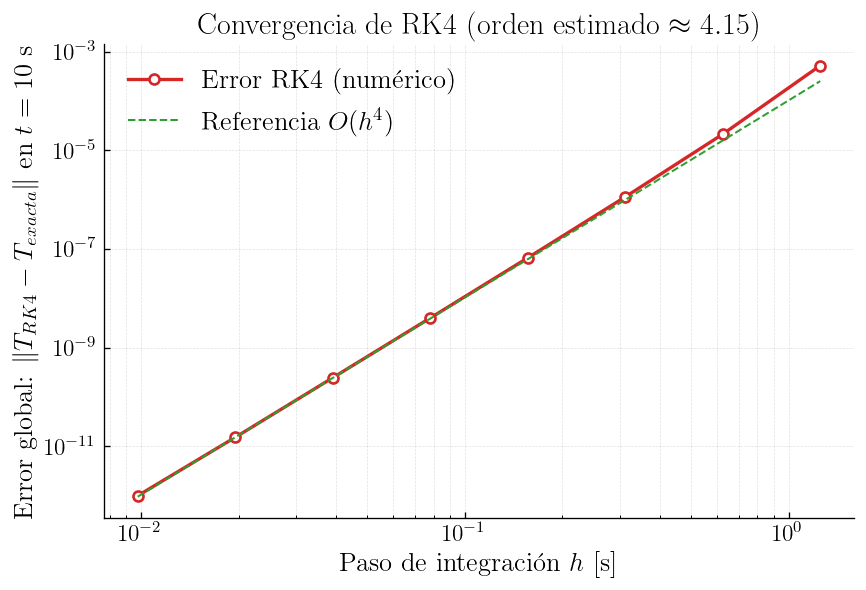

In [73]:
fig, ax = plt.subplots(figsize=(7.5, 5.2))

# Escala log-log: un método O(h^p) aparece como una recta de pendiente p
ax.loglog(hs, errores, color=COL_CPU, lw=2, marker="o", ms=6,
          markerfacecolor="white", markeredgewidth=1.6, label="Error RK4 (numérico)")

# Línea de referencia con pendiente teórica 4, anclada al último punto
h_ref = np.array([hs.min(), hs.max()])
C_ref = errores[-2] / hs[-2] ** 4
ax.loglog(h_ref, C_ref * h_ref ** 4, ls="--", color=COL_REF, lw=1.2, label=r"Referencia $O(h^4)$")

ax.set_xlabel(r"Paso de integración $h$ [s]")
ax.set_ylabel(r"Error global: $\|T_{RK4} - T_{exacta}\|$ en $t=10$ s")
ax.set_title(rf"Convergencia de RK4 (orden estimado $\approx {pendiente:.2f}$)")
ax.legend(loc="upper left", frameon=False)
ax.grid(True, which="both", alpha=0.25, linewidth=0.4)

plt.tight_layout()
plt.savefig("fig4_convergencia_rk4.png")
plt.show()

**Figura 4.** Error global de la integración RK4 respecto a la solución analítica exacta, en función del paso $h$, en escala log-log. Los puntos siguen de cerca la recta de referencia de pendiente 4 (línea gris discontinua), confirmando que el integrador implementado alcanza el orden teórico $O(h^4)$ esperado para Runge–Kutta de 4º orden. El paso usado en la simulación principal ($h=0.1$ s) está muy por debajo del régimen donde el error de truncamiento es relevante, por lo que los resultados de las Figuras 1–3 pueden considerarse numéricamente confiables.

## 10. Conclusiones

* La CPU se estabiliza alrededor de $48.8\,^\circ$C, el cold plate en $36.8\,^\circ$C y el agua de salida en $22.1\,^\circ$C, partiendo todos de $25\,^\circ$C.
* El sistema alcanza el estado estacionario en poco más de un minuto ($t_{asent.} \approx 72$ s), con la CPU respondiendo primero y el agua estabilizándose más lentamente por su mayor capacidad térmica y su acoplamiento indirecto con la fuente de calor.
* El balance de energía se cumple. En estado estacionario prácticamente toda la potencia disipada por la CPU (≈ 98%) es removida por el agua y sólo una fracción menor (≈ 2%) se disipa al aire lo cual confirma cuantitativamente lo descrito en el planteamiento del problema.
* La solución RK4 se validó de dos formas independientes. Se concluye que:

1.   Coincide con la solución analítica del sistema lineal con error menor a $10^{-9}\,^\circ$C en $t_{final}$
2.   Su error de truncamiento decrece con pendiente ≈ 4 en escala log-log, como se espera teóricamente de un método de orden 4.

En conjunto, estos resultados muestran que el modelo de EDOS ordinarias para este problema es una herramienta válida para el diseño, la estimación y el control térmico del sistema de refrigeración líquida.

---
### Referencias

* Presentación del problema: *Paso de un modelo microscópico a un modelo macroscópico — Sistema de refrigeración líquida por cold plate*, T. Serna, Julio de 2026.